In [1]:
import utils
import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import pandas as pd
import numpy as np

2026-02-18 22:05:08.092895: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 22:05:08.618881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771448708.788399   26445 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771448708.838150   26445 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-18 22:05:09.292463: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
(train_x, train_y), (test_x, test_y) = utils.read_stratified_data(columns=("model", "year", "lighting"))

datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg


(3630, 300, 300, 3)
(3630, 10)
(639, 300, 300, 3)
(639, 10)
      annotation_id  annotator            color                   created_at  \
1772           2467          1            White  2026-02-04T16:31:16.491893Z   
1811            507          1            White  2026-02-03T14:47:43.760883Z   
41               49          1             Blue  2026-02-05T08:26:13.667527Z   
1268            626          1  Black/Dark gray  2026-02-05T13:37:30.888238Z   
580             594          1  Black/Dark gray  2026-02-05T13:25:12.870353Z   
...             ...        ...              ...                          ...   
1858            561          1            White  2026-02-03T14:58:40.907195Z   
2328           3127          1             Blue  2026-02-13T13:58:41.799879Z   
1898            606          1  Black/Dark gray  2026-02-03T15:04:43.370901Z   
862             342          1            White  2026-02-05T12:37:26.058615Z   
2179           3087          1  Black/Dark gray  2026-02-05T

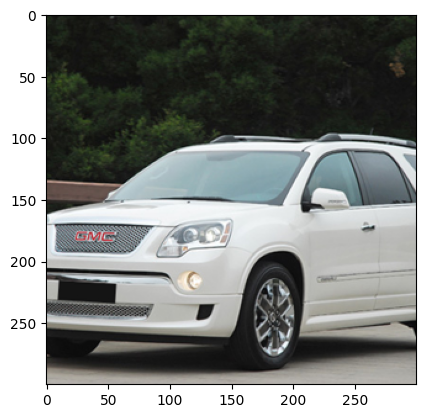

In [ ]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

i = 93
print(train_y)
plt.imshow(train_x[i])
plt.show()

In [ ]:
i = 0

annotation_id                           2467
annotator                                  1
color                                  White
created_at       2026-02-04T16:31:16.491893Z
id                                      2465
lead_time                              3.431
lighting                               Light
model                              Other car
updated_at       2026-02-04T16:31:16.491893Z
year                                     NaN
Name: 1772, dtype: object


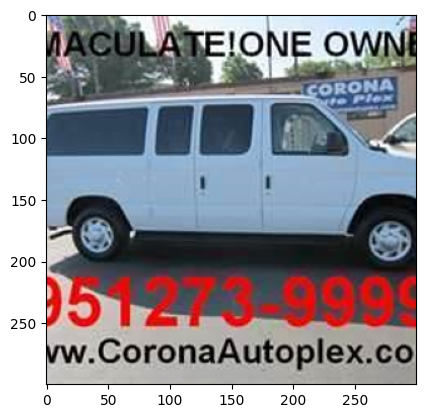

In [ ]:
print(train_y.iloc[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [ ]:
train_y_new = train_y["model"]

def t(x):
    if x == 'Other car':
        return 1
    return 0

vt = np.vectorize(t)

train_y_new = vt(train_y_new)

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y_new,
    epochs=epochs,
)

[1 0 0 1 1 0 1 0 1 1]
Epoch 1/5


I0000 00:00:1771448358.787015   23777 service.cc:148] XLA service 0x77cd800041e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771448358.788212   23777 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-18 21:59:18.878331: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771448359.084607   23777 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/114 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4298 - loss: 0.8960

I0000 00:00:1771448364.243189   23777 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


114/114 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7022 - loss: 0.5735
Epoch 2/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8165 - loss: 0.4232
Epoch 3/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8620 - loss: 0.3289
Epoch 4/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9011 - loss: 0.2542
Epoch 5/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9361 - loss: 0.1834


In [ ]:
test_y_new = test_y["model"]
test_y_new = vt(test_y_new)

functional_model.evaluate(test_x, test_y_new)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8247 - loss: 0.4562


[0.45621082186698914, 0.8247261643409729]

```
['Dark-Other car--Orange', 'Light-S-2021–nå-Light gray/Silver']
Mangler orange bil, mørk og Nyeste model S grå/sølv i lys for å kunne stratifisere på 'color'
Har Ekskludert nyeste model X for å kunne stratifisere på 'year'
```

In [ ]:
print(train_x.shape)
print(train_y.shape)

print(test_x.shape)
print(test_y.shape)

(3630, 300, 300, 3)
(3630, 10)
(639, 300, 300, 3)
(639, 10)


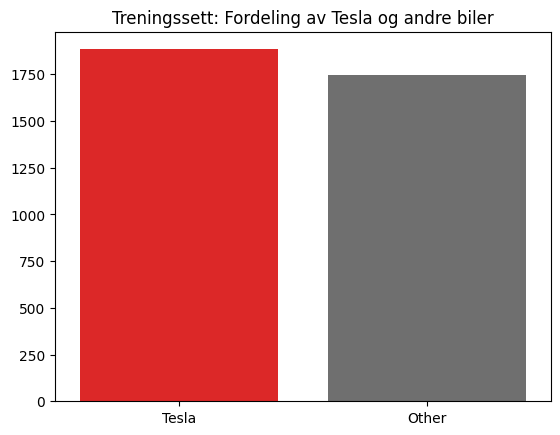

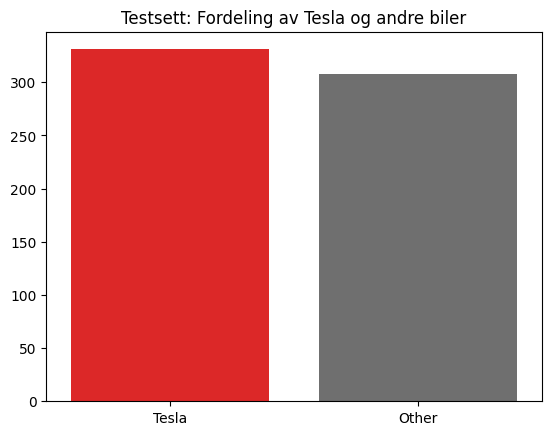

In [ ]:
df = train_y
other = 'Other car'

names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
plt.show()

df = test_y
names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Testsett: Fordeling av Tesla og andre biler')
plt.show()

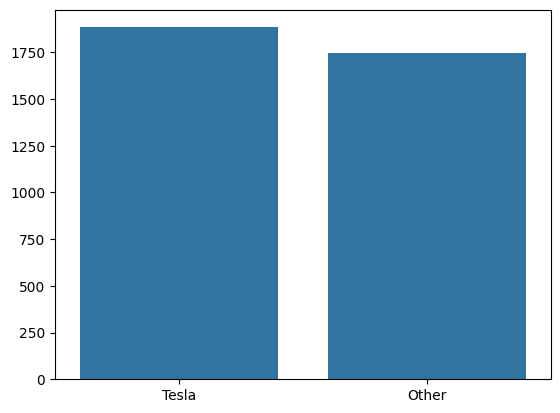

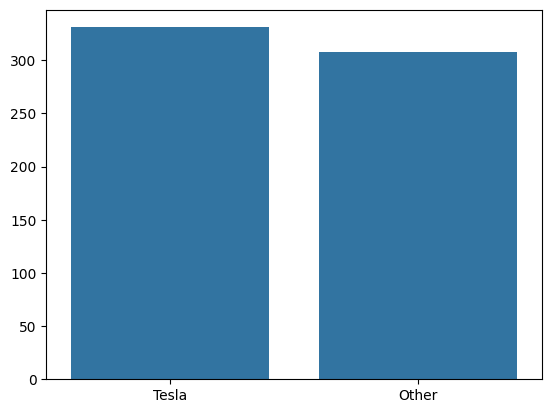

In [ ]:
df = train_y
tesla = df[df['model'] != other]
others = df[df['model'] == other]


sns.barplot(data={'Tesla':len(tesla), 'Other': len(others)})
plt.show()

df = test_y
tesla = df[df['model'] != other]
others = df[df['model'] == other]

sns.barplot(data={'Tesla':len(tesla), 'Other': len(others)})
plt.show()

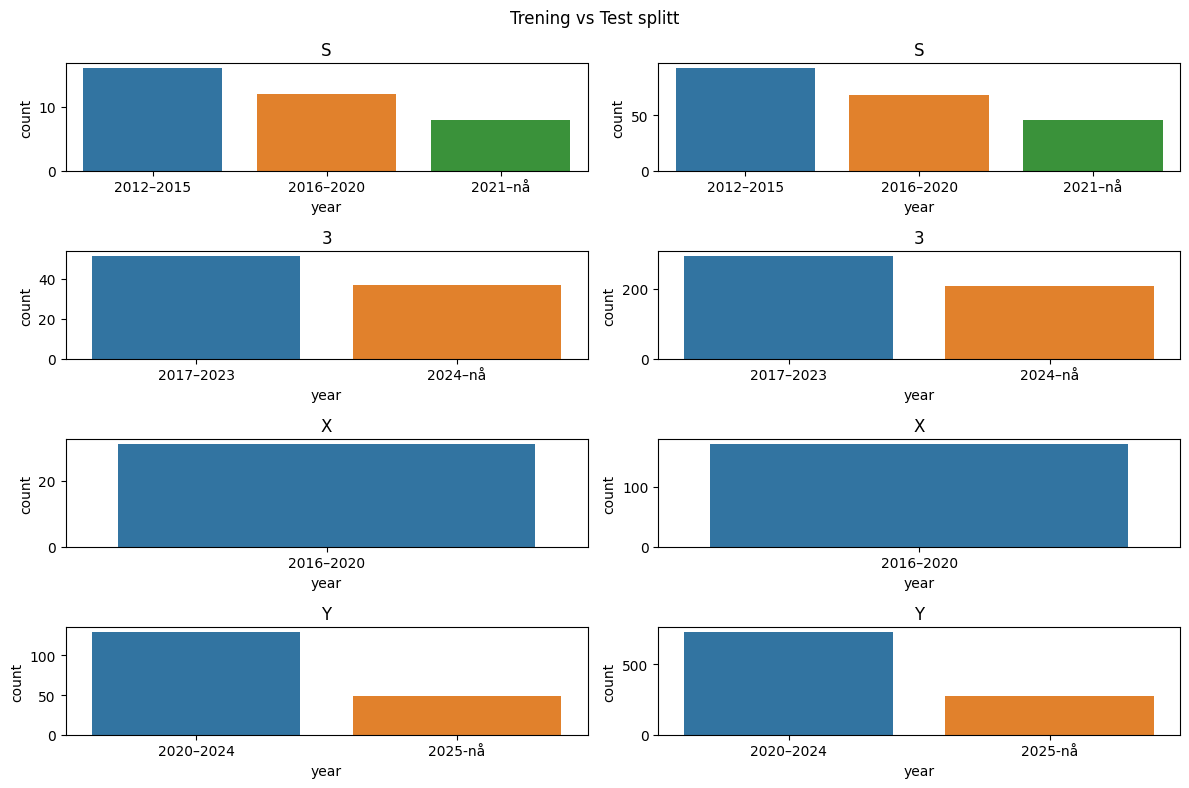

In [ ]:
train_y_split = [
    train_y[train_y['model'] == 'S'].sort_values('year'),
    train_y[train_y['model'] == '3'].sort_values('year'),
    train_y[train_y['model'] == 'X'].sort_values('year'),
    train_y[train_y['model'] == 'Y'].sort_values('year')
]
test_y_split = [
    test_y[test_y['model'] == 'S'].sort_values('year'),
    test_y[test_y['model'] == '3'].sort_values('year'),
    test_y[test_y['model'] == 'X'].sort_values('year'),
    test_y[test_y['model'] == 'Y'].sort_values('year')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='year', data=train_y_split[i*2 + j], ax=axes[i*2+j,1], hue='year')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='year', data=test_y_split[i*2 + j], ax=axes[i*2+j,0], hue='year')
        axes[i*2+j,1].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

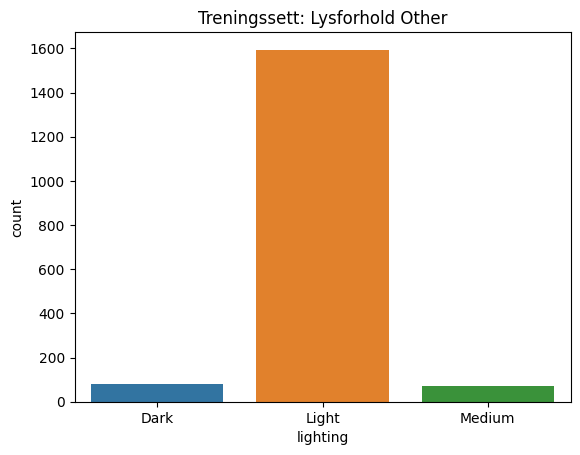

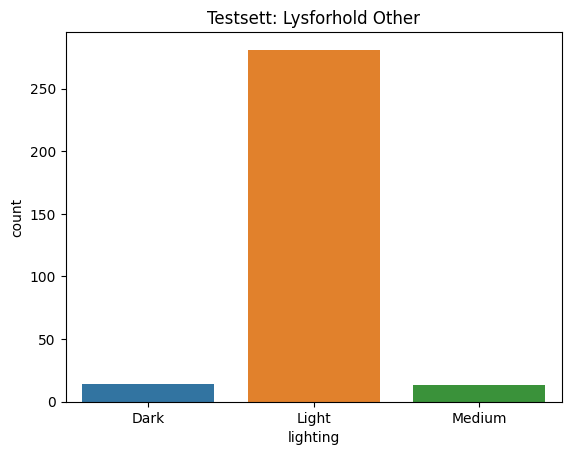

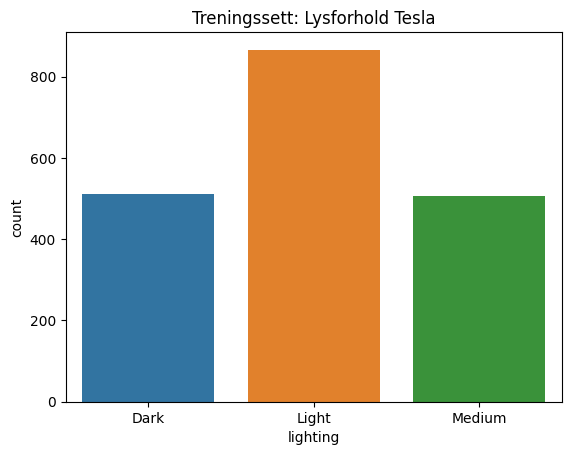

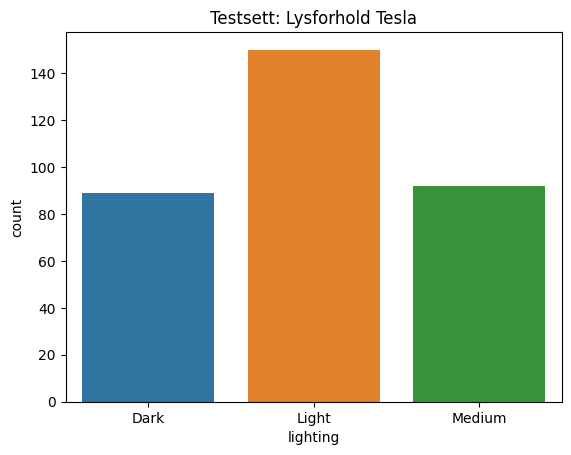

In [ ]:
df = train_y[train_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Other')
plt.show()

df = test_y[test_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Other')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Tesla')
plt.show()